In [23]:
#URl = https://www.kaggle.com/competitions/playground-series-s6e1/overview

In [24]:
import pandas as pd
dataset = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Predicting_Student_Test_Scores/train.csv',
                         index_col = 'id')
dataset.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [25]:
dataset.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<Axes: xlabel='internet_access', ylabel='exam_score'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


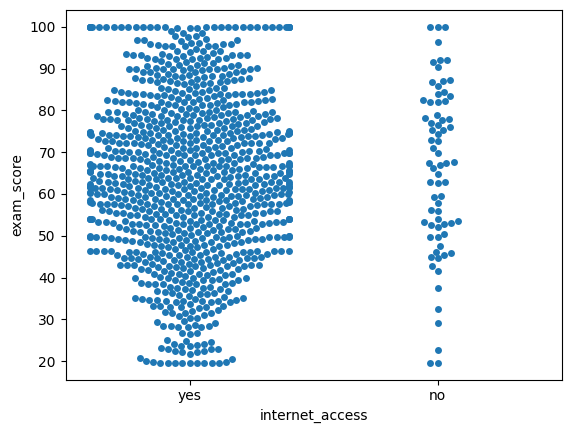

In [26]:
import seaborn as sns
sample = dataset.sample(1000)
sns.swarmplot(x = sample['internet_access'],y = sample['exam_score'])

<Axes: xlabel='class_attendance', ylabel='exam_score'>

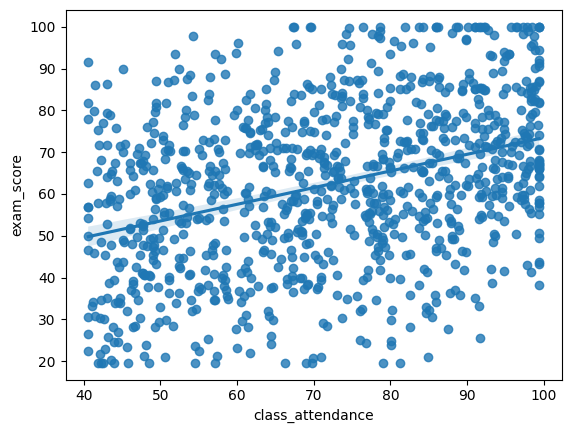

In [27]:
sample = dataset.sample(1000)
sns.regplot(x = sample['class_attendance'], y = sample['exam_score'])

In [28]:
dataset.drop(columns='exam_difficulty',inplace = True)
dataset.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_score'],
      dtype='object')

In [29]:
Or_cols = ['sleep_quality','facility_rating']
Oh_cols = [col for col in dataset.columns if dataset[col].dtype == 'object' and (col in Or_cols) == False]
num_cols = [col for col in dataset.columns if dataset[col].dtype != 'object' and  col != 'exam_score']

x_train = dataset.copy().drop(columns = 'exam_score')
y_train = dataset['exam_score']

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
preprocess = ColumnTransformer(
    transformers = [
        ('num',SimpleImputer(),num_cols),
        ('Or_cat',OrdinalEncoder(),Or_cols),
        ('Oh_cat',OneHotEncoder(handle_unknown='ignore'),Oh_cols)
    ]
)
model = Pipeline([
    ('pre_processor',preprocess),
    ('xgboost',XGBRegressor())
])

In [31]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

scores = cross_val_score(
    model,
    x_train,
    y_train,
    cv = kf,
    scoring = 'neg_mean_squared_error'
)
print(-scores.mean())

77.5647718455969


In [32]:
model.fit(x_train,y_train)

Pipeline(steps=[('pre_processor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['age', 'study_hours',
                                                   'class_attendance',
                                                   'sleep_hours']),
                                                 ('Or_cat', OrdinalEncoder(),
                                                  ['sleep_quality',
                                                   'facility_rating']),
                                                 ('Oh_cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'course',
                                                   'internet_access',
                                                   'study_method'])])),
                ('xgboost',
                 XGBRegressor(base_score=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [34]:
test = pd.read_csv('https://huggingface.co/datasets/NHANGIOI/Learning-Training/resolve/main/Predicting_Student_Test_Scores/test.csv',
                   index_col = 'id')
test.drop(columns = 'exam_difficulty',inplace = True)
pred = model.predict(test)
submission = pd.DataFrame({
    "id" : test.index,
    "exam_score" : pred
})